# 🛡️ QuantumCyberGuard
## Seguridad inteligente para entornos pre y post-cuánticos

**Semillero de investigación**

Este notebook implementa un pipeline completo de ciberseguridad con IA y simulación cuántica:

1. **EDA** – Análisis exploratorio del dataset Global Cybersecurity Threats 2015-2024  
2. **Random Forest** – Clasificador supervisado de anomalías  
3. **LSTM Autoencoder** – Detección no supervisada con redes recurrentes  
4. **Isolation Forest + PCA** – Detección no supervisada clásica  
5. **Autoencoder Denso** – Red neuronal para reconstrucción de anomalías  
6. **Algoritmo de Grover (Qiskit)** – Estimación de tiempos de ataque cuántico  


## 0. Instalación de dependencias

In [3]:
!pip install imbalanced-learn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: C:\Python312\python.exe -m pip install --upgrade pip


In [1]:
# Descomenta si estás en Google Colab o entorno sin las librerías instaladas
!pip install qiskit qiskit-aer imbalanced-learn tensorflow scikit-learn pandas matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: C:\Python312\python.exe -m pip install --upgrade pip


## 1. Importaciones globales

In [33]:
import sys
!{sys.executable} -m pip install qiskit qiskit-aer imbalanced-learn tensorflow scikit-learn pandas matplotlib seaborn

     ---------------------------------------- 0.0/8.6 MB ? eta -:--:--
      --------------------------------------- 0.2/8.6 MB 4.5 MB/s eta 0:00:02
     - -------------------------------------- 0.3/8.6 MB 3.4 MB/s eta 0:00:03
     - -------------------------------------- 0.3/8.6 MB 2.4 MB/s eta 0:00:04
     - -------------------------------------- 0.4/8.6 MB 2.5 MB/s eta 0:00:04
     -- ------------------------------------- 0.6/8.6 MB 2.7 MB/s eta 0:00:03
     --- ------------------------------------ 0.7/8.6 MB 2.7 MB/s eta 0:00:03
     --- ------------------------------------ 0.9/8.6 MB 2.9 MB/s eta 0:00:03
     ---- ----------------------------------- 1.0/8.6 MB 2.9 MB/s eta 0:00:03
     ----- ---------------------------------- 1.1/8.6 MB 3.0 MB/s eta 0:00:03
     ----- ---------------------------------- 1.2/8.6 MB 2.9 MB/s eta 0:00:03
     ------ --------------------------------- 1.4/8.6 MB 3.0 MB/s eta 0:00:03
     ------ --------------------------------- 1.5/8.6 MB 2.9 MB/s eta 0


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import math
import os
import warnings
warnings.filterwarnings("ignore")

# Scikit-learn
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, roc_curve, roc_auc_score,
                              precision_recall_curve, average_precision_score)
from sklearn.feature_selection import SelectKBest, f_classif
from imblearn.over_sampling import SMOTE
from scipy.stats import chi2_contingency

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import (Input, Dense, LSTM, Dropout,
                                      RepeatVector, TimeDistributed)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import MeanSquaredError
import joblib

print("✅ Todas las librerías importadas correctamente")
print(f"   TF version: {tf.__version__}")

✅ Todas las librerías importadas correctamente
   TF version: 2.20.0


---
## 2. Análisis Exploratorio de Datos (EDA)

In [44]:
# Carga del dataset
df = pd.read_csv(r"C:\Users\Acer\OneDrive\Escritorio\CARPETAS\septimo semestre\ponencia\data\Global_Cybersecurity_Threats_2015-2024.csv")
df

,Country,Year,Attack Type,Target Industry,Financial Loss (in Million $),Number of Affected Users,Attack Source,Security Vulnerability Type,Defense Mechanism Used,Incident Resolution Time (in Hours)
0,China,2019,Phishing,Education,80.53,773169,Hacker Group,Unpatched Software,VPN,63
1,China,2019,Ransomware,Retail,62.19,295961,Hacker Group,Unpatched Software,Firewall,71
2,India,2017,Man-in-the-Middle,IT,38.65,605895,Hacker Group,Weak Passwords,VPN,20
3,UK,2024,Ransomware,Telecommunications,41.44,659320,Nation-state,Social Engineering,AI-based Detection,7
4,Germany,2018,Man-in-the-Middle,IT,74.41,810682,Insider,Social Engineering,VPN,68
...,...,...,...,...,...,...,...,...,...,...
2995,UK,2021,Ransomware,Government,51.42,190694,Unknown,Social Engineering,Firewall,52
2996,Brazil,2023,SQL Injection,Telecommunications,30.28,892843,Hacker Group,Zero-day,VPN,26
2997,Brazil,2017,SQL Injection,IT,32.97,734737,Nation-state,Weak Passwords,AI-based Detection,30
2998,UK,2022,SQL Injection,IT,32.17,379954,Insider,Unpatched Software,Firewall,9


In [45]:
df.shape

(3000, 10)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 10 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Country                              3000 non-null   object 
 1   Year                                 3000 non-null   int64  
 2   Attack Type                          3000 non-null   object 
 3   Target Industry                      3000 non-null   object 
 4   Financial Loss (in Million $)        3000 non-null   float64
 5   Number of Affected Users             3000 non-null   int64  
 6   Attack Source                        3000 non-null   object 
 7   Security Vulnerability Type          3000 non-null   object 
 8   Defense Mechanism Used               3000 non-null   object 
 9   Incident Resolution Time (in Hours)  3000 non-null   int64  
dtypes: float64(1), int64(3), object(6)
memory usage: 234.5+ KB


In [4]:
df.describe()

,Year,Financial Loss (in Million $),Number of Affected Users,Incident Resolution Time (in Hours)
count,3000.000000,3000.000000,3000.000000,3000.000000
mean,2019.570333,50.492970,504684.136333,36.476000
std,2.857932,28.791415,289944.084972,20.570768
min,2015.000000,0.500000,424.000000,1.000000
25%,2017.000000,25.757500,255805.250000,19.000000
50%,2020.000000,50.795000,504513.000000,37.000000
75%,2022.000000,75.630000,758088.500000,55.000000
max,2024.000000,99.990000,999635.000000,72.000000


In [46]:
missing_values = df.isnull().sum()
missing_values

Country                                0
Year                                   0
Attack Type                            0
Target Industry                        0
Financial Loss (in Million $)          0
Number of Affected Users               0
Attack Source                          0
Security Vulnerability Type            0
Defense Mechanism Used                 0
Incident Resolution Time (in Hours)    0
dtype: int64

In [7]:
# Distribución de variables categóricas
categorical_cols = df.select_dtypes(include=["object"]).columns
for col in categorical_cols:
    print(f"{col}:")
    print(df[col].value_counts())

Country:
Country
UK           321
Brazil       310
India        308
Japan        305
France       305
Australia    297
Russia       295
Germany      291
USA          287
China        281
Name: count, dtype: int64
Attack Type:
Attack Type
DDoS                 531
Phishing             529
SQL Injection        503
Ransomware           493
Malware              485
Man-in-the-Middle    459
Name: count, dtype: int64
Target Industry:
Target Industry
IT                    478
Banking               445
Healthcare            429
Retail                423
Education             419
Government            403
Telecommunications    403
Name: count, dtype: int64
Attack Source:
Attack Source
Nation-state    794
Unknown         768
Insider         752
Hacker Group    686
Name: count, dtype: int64
Security Vulnerability Type:
Security Vulnerability Type
Zero-day              785
Social Engineering    747
Unpatched Software    738
Weak Passwords        730
Name: count, dtype: int64
Defense Mechanism Used:

In [47]:
# Manejo de valores atípicos en pérdidas financieras y número de afectados
columns_to_check = ['Financial Loss (in Million $)', 'Number of Affected Users', 'Incident Resolution Time (in Hours)']
outliers_info = {}

for col in columns_to_check:
    if col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Contar valores atípicos antes de eliminarlos
        num_outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
        outliers_info[col] = {
            "Q1": Q1,
            "Q3": Q3,
            "IQR": IQR,
            "Lower Bound": lower_bound,
            "Upper Bound": upper_bound,
            "Number of Outliers": num_outliers
        }

outliers_info


{'Financial Loss (in Million $)': {'Q1': np.float64(25.7575),
  'Q3': np.float64(75.63),
  'IQR': np.float64(49.872499999999995),
  'Lower Bound': np.float64(-49.05124999999999),
  'Upper Bound': np.float64(150.43874999999997),
  'Number of Outliers': np.int64(0)},
 'Number of Affected Users': {'Q1': np.float64(255805.25),
  'Q3': np.float64(758088.5),
  'IQR': np.float64(502283.25),
  'Lower Bound': np.float64(-497619.625),
  'Upper Bound': np.float64(1511513.375),
  'Number of Outliers': np.int64(0)},
 'Incident Resolution Time (in Hours)': {'Q1': np.float64(19.0),
  'Q3': np.float64(55.0),
  'IQR': np.float64(36.0),
  'Lower Bound': np.float64(-35.0),
  'Upper Bound': np.float64(109.0),
  'Number of Outliers': np.int64(0)}}

### 2.1 Visualizaciones EDA

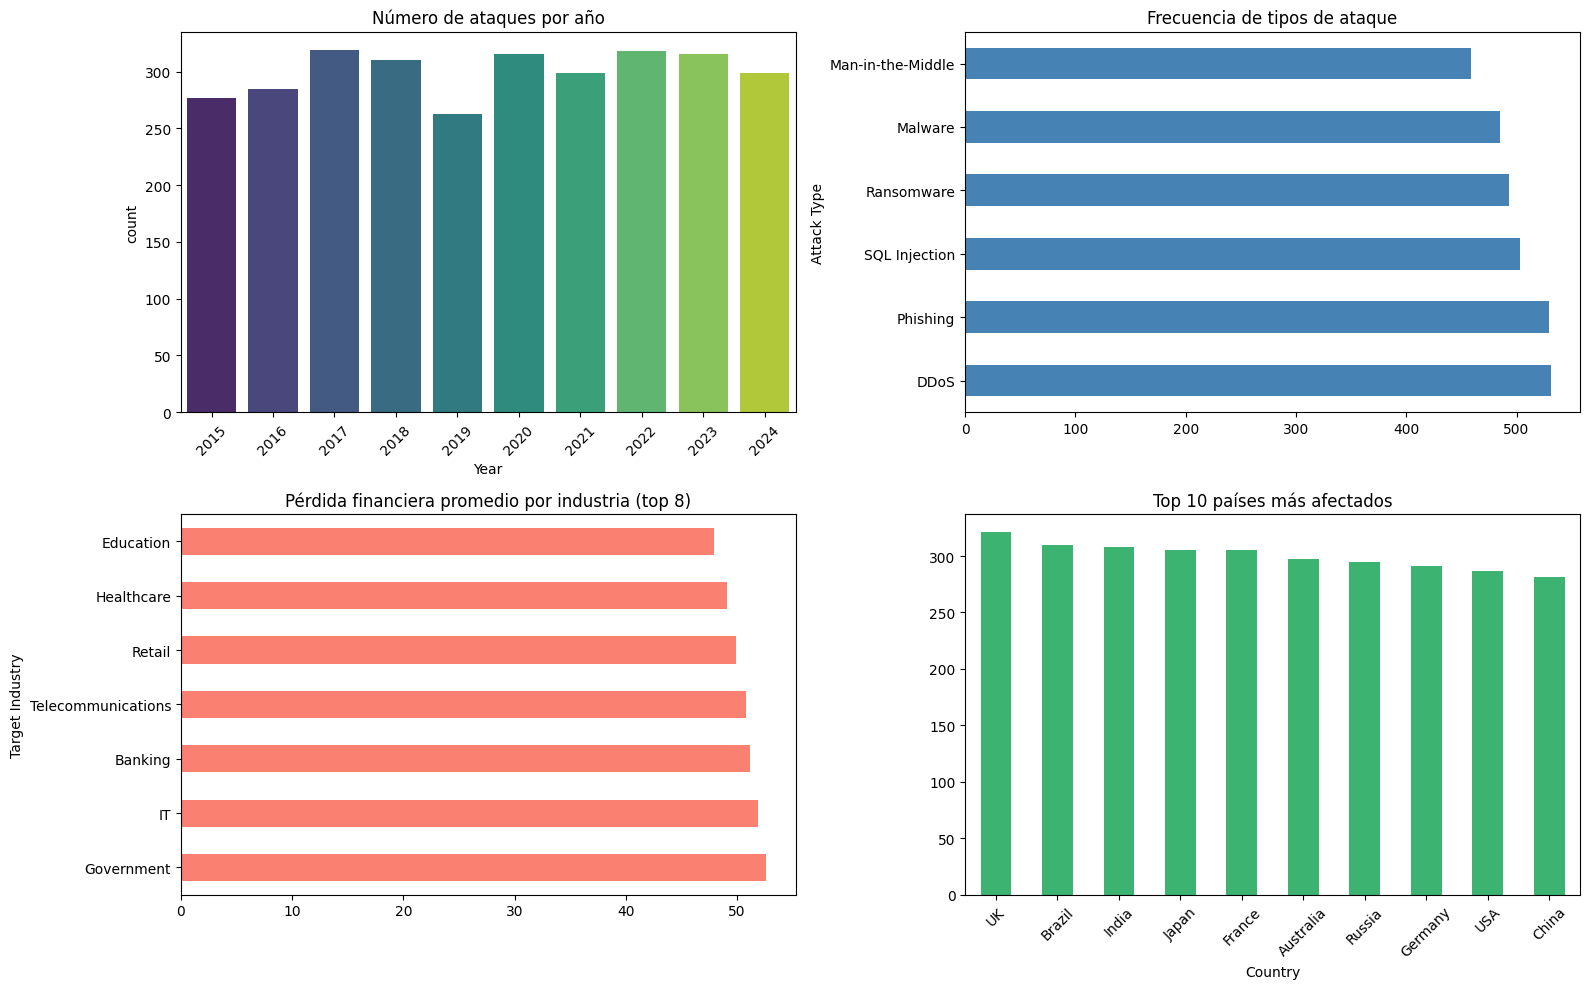

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Ataques por año
sns.countplot(data=df, x="Year", palette="viridis", ax=axes[0,0])
axes[0,0].set_title("Número de ataques por año")
axes[0,0].tick_params(axis="x", rotation=45)

# Frecuencia de tipos de ataque
df["Attack Type"].value_counts().plot(kind="barh", ax=axes[0,1], color="steelblue")
axes[0,1].set_title("Frecuencia de tipos de ataque")

# Pérdidas por industria
top_industries = df.groupby("Target Industry")["Financial Loss (in Million $)"].mean().nlargest(8)
top_industries.plot(kind="barh", ax=axes[1,0], color="salmon")
axes[1,0].set_title("Pérdida financiera promedio por industria (top 8)")

# Top 10 países más afectados
df["Country"].value_counts().head(10).plot(kind="bar", ax=axes[1,1], color="mediumseagreen")
axes[1,1].set_title("Top 10 países más afectados")
axes[1,1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("eda_overview.png", dpi=120, bbox_inches="tight")
plt.show()

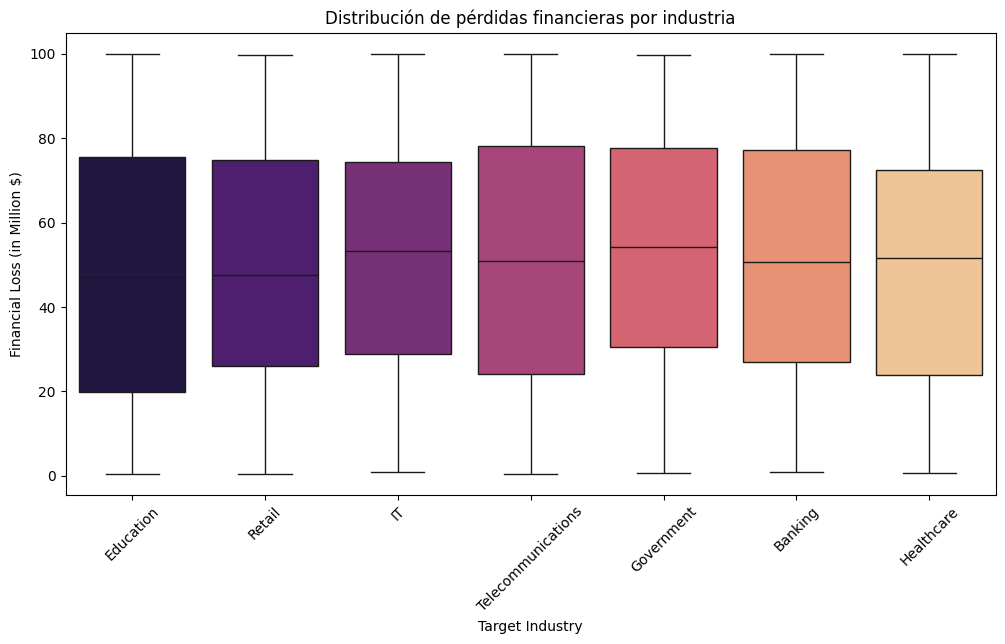

In [48]:
# Gráfico de pérdidas financieras por industria
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="Target Industry", y="Financial Loss (in Million $)", palette="magma")
plt.title("Distribución de pérdidas financieras por industria")
plt.xticks(rotation=45)
plt.show()


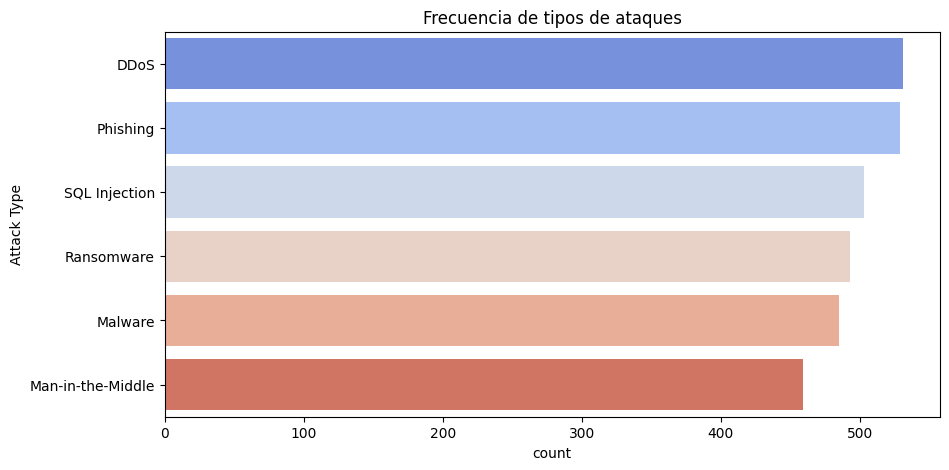

In [49]:

# Gráfico de ataques por tipo
plt.figure(figsize=(10, 5))
sns.countplot(data=df, y="Attack Type", order=df["Attack Type"].value_counts().index, palette="coolwarm")
plt.title("Frecuencia de tipos de ataques")
plt.show()


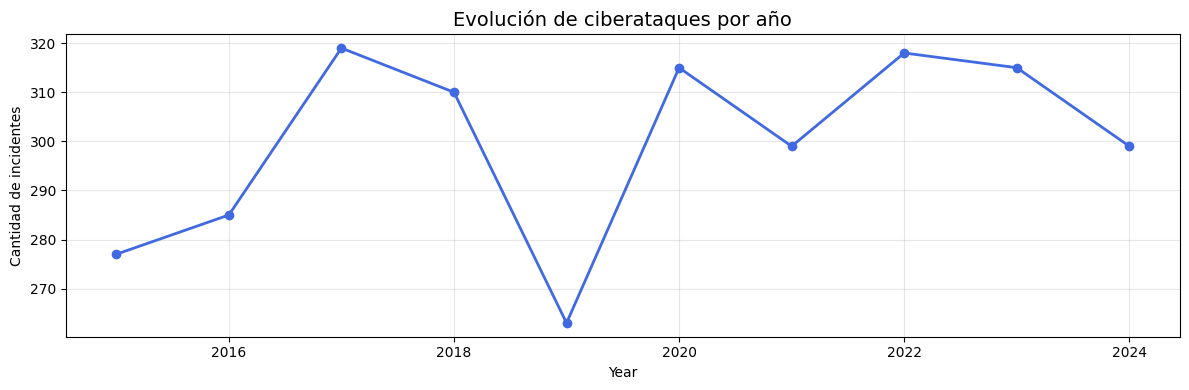

In [10]:
# Evolución temporal
plt.figure(figsize=(12, 4))
df.groupby("Year").size().plot(marker="o", linewidth=2, color="royalblue")
plt.title("Evolución de ciberataques por año", fontsize=14)
plt.ylabel("Cantidad de incidentes")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

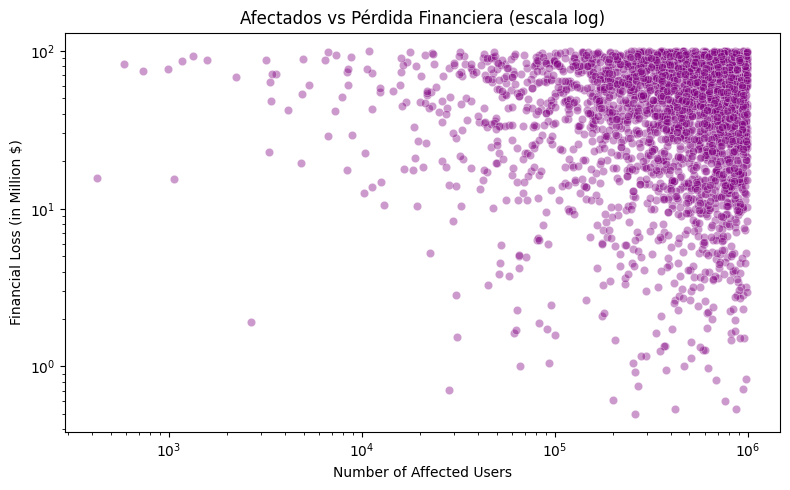

In [11]:
# Relación afectados vs pérdida
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df["Number of Affected Users"],
                y=df["Financial Loss (in Million $)"],
                alpha=0.4, color="purple")
plt.xscale("log"); plt.yscale("log")
plt.title("Afectados vs Pérdida Financiera (escala log)")
plt.tight_layout()
plt.show()

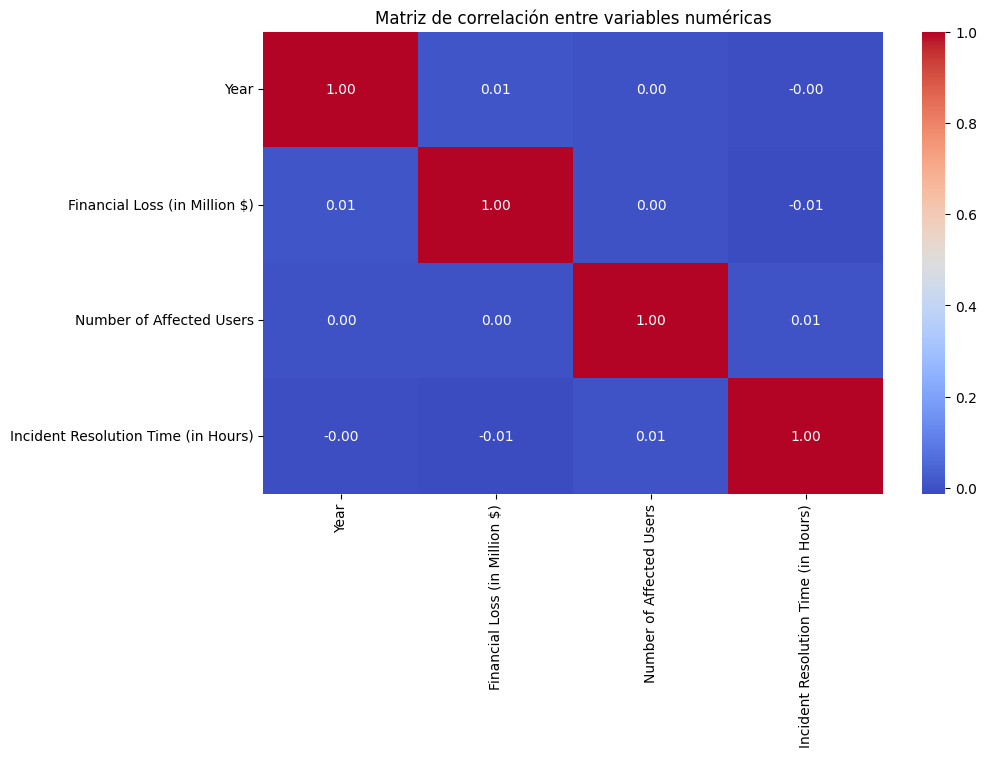

In [53]:
# Filtrar solo las columnas numéricas para la matriz de correlación
numeric_cols = df.select_dtypes(include=['number'])

plt.figure(figsize=(10, 6))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Matriz de correlación entre variables numéricas")
plt.show()


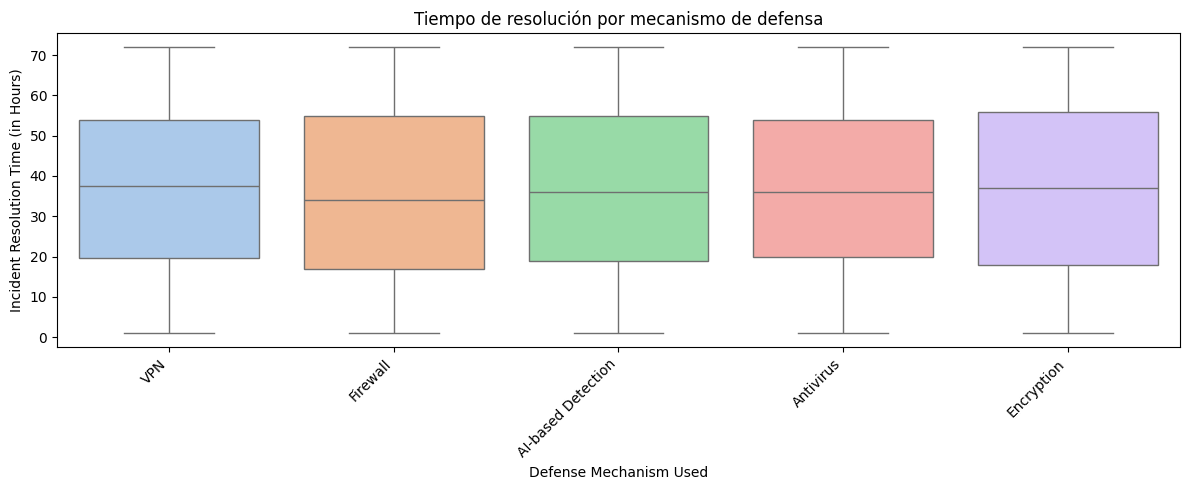

In [52]:
# Efectividad de mecanismos de defensa
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x="Defense Mechanism Used",
            y="Incident Resolution Time (in Hours)", palette="pastel")
plt.xticks(rotation=45, ha="right")
plt.title("Tiempo de resolución por mecanismo de defensa")
plt.tight_layout()
plt.show()

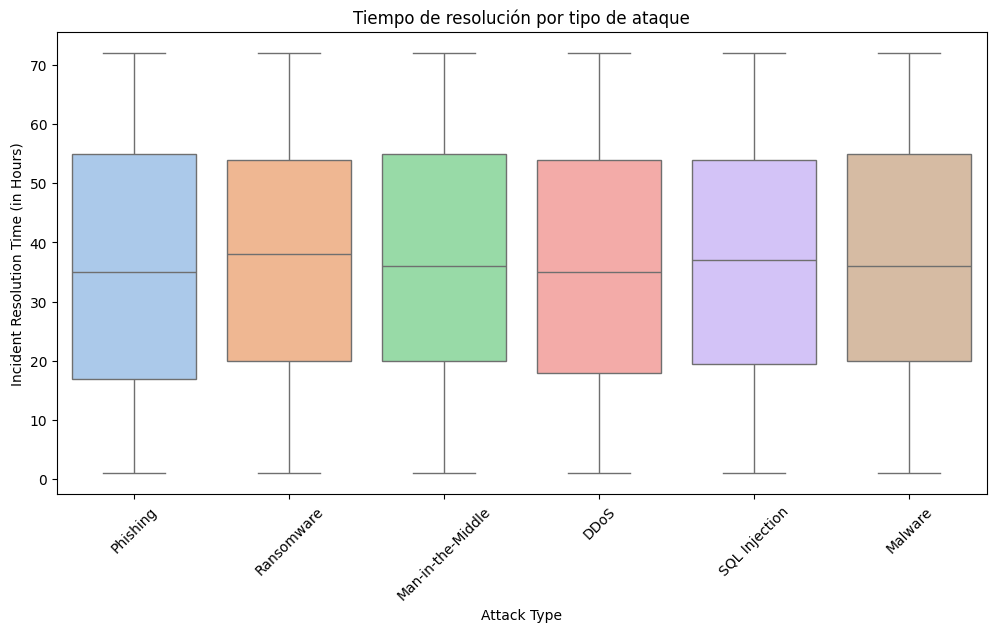

In [51]:

# Gráfico de tiempo de resolución por tipo de ataque
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="Attack Type", y="Incident Resolution Time (in Hours)", palette="pastel")
plt.title("Tiempo de resolución por tipo de ataque")
plt.xticks(rotation=45)
plt.show()

---
## 3. Preprocesamiento para Modelos ML

In [55]:
# Copia de trabajo
df_model = df.copy()

# Creación de una nueva variable de riesgo relativo
df['Risk Score'] = df['Financial Loss (in Million $)'] / (df['Number of Affected Users'] + 1)
df['Risk Score']

0       0.000104
1       0.000210
2       0.000064
3       0.000063
4       0.000092
          ...   
2995    0.000270
2996    0.000034
2997    0.000045
2998    0.000085
2999    0.000100
Name: Risk Score, Length: 3000, dtype: float64

In [56]:
# Normalización del tiempo de resolución
df['Normalized Resolution Time'] = df['Incident Resolution Time (in Hours)'] / df.groupby('Attack Type')['Incident Resolution Time (in Hours)'].transform('mean')
df['Normalized Resolution Time']

0       1.754237
1       1.943423
2       0.542425
3       0.191605
4       1.844245
          ...   
2995    1.423352
2996    0.704482
2997    0.812864
2998    0.243859
2999    1.734109
Name: Normalized Resolution Time, Length: 3000, dtype: float64

In [57]:
# One-Hot Encoding de variables categóricas
df_encoded = pd.get_dummies(df, columns=['Attack Type', 'Target Industry', 'Attack Source', 'Security Vulnerability Type', 'Defense Mechanism Used'])
df_encoded

,Country,Year,Financial Loss (in Million $),Number of Affected Users,Incident Resolution Time (in Hours),Risk Score,Normalized Resolution Time,Attack Type_DDoS,Attack Type_Malware,Attack Type_Man-in-the-Middle,...,Attack Source_Unknown,Security Vulnerability Type_Social Engineering,Security Vulnerability Type_Unpatched Software,Security Vulnerability Type_Weak Passwords,Security Vulnerability Type_Zero-day,Defense Mechanism Used_AI-based Detection,Defense Mechanism Used_Antivirus,Defense Mechanism Used_Encryption,Defense Mechanism Used_Firewall,Defense Mechanism Used_VPN
0,China,2019,80.53,773169,63,0.000104,1.754237,False,False,False,...,False,False,True,False,False,False,False,False,False,True
1,China,2019,62.19,295961,71,0.000210,1.943423,False,False,False,...,False,False,True,False,False,False,False,False,True,False
2,India,2017,38.65,605895,20,0.000064,0.542425,False,False,True,...,False,False,False,True,False,False,False,False,False,True
3,UK,2024,41.44,659320,7,0.000063,0.191605,False,False,False,...,False,True,False,False,False,True,False,False,False,False
4,Germany,2018,74.41,810682,68,0.000092,1.844245,False,False,True,...,False,True,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,UK,2021,51.42,190694,52,0.000270,1.423352,False,False,False,...,True,True,False,False,False,False,False,False,True,False
2996,Brazil,2023,30.28,892843,26,0.000034,0.704482,False,False,False,...,False,False,False,False,True,False,False,False,False,True
2997,Brazil,2017,32.97,734737,30,0.000045,0.812864,False,False,False,...,False,False,False,True,False,True,False,False,False,False
2998,UK,2022,32.17,379954,9,0.000085,0.243859,False,False,False,...,False,False,True,False,False,False,False,False,True,False


In [59]:
# Codificamos columnas categóricas
categorical_cols = df_model.select_dtypes(include='object').columns
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    label_encoders[col] = le

# Seleccionar solo columnas numéricas
features = df_model.select_dtypes(include=['int64', 'float64'])

In [60]:
from scipy.stats import chi2_contingency
for col in ['Country', 'Target Industry', 'Attack Source', 'Security Vulnerability Type', 'Defense Mechanism Used']:
    contingency_table = pd.crosstab(df[col], df['Attack Type'])
    chi2, p, _, _ = chi2_contingency(contingency_table)
    print(f"{col}: chi2={chi2:.2f}, p-value={p:.4f}")

Country: chi2=41.61, p-value=0.6163
Target Industry: chi2=38.46, p-value=0.1384
Attack Source: chi2=9.71, p-value=0.8377
Security Vulnerability Type: chi2=23.18, p-value=0.0805
Defense Mechanism Used: chi2=21.75, p-value=0.3542


In [61]:
print(df_model.isnull().sum())
df_model = df_model.dropna()  # O imputa valores faltantes

Country                                0
Year                                   0
Attack Type                            0
Target Industry                        0
Financial Loss (in Million $)          0
Number of Affected Users               0
Attack Source                          0
Security Vulnerability Type            0
Defense Mechanism Used                 0
Incident Resolution Time (in Hours)    0
Risk Score                             0
IsAnomaly                              0
dtype: int64


In [63]:
# Paso 2: Crear la columna 'IsAnomaly' en df_model
# Usaremos los percentiles 5 y 95 para marcar valores extremos como anomalías

# Definir umbrales por variable usando df_model
loss_threshold_high = df_model['Financial Loss (in Million $)'].quantile(0.95)
loss_threshold_low = df_model['Financial Loss (in Million $)'].quantile(0.05)

users_threshold_high = df_model['Number of Affected Users'].quantile(0.95)
users_threshold_low = df_model['Number of Affected Users'].quantile(0.05)

time_threshold_high = df_model['Incident Resolution Time (in Hours)'].quantile(0.95)
time_threshold_low = df_model['Incident Resolution Time (in Hours)'].quantile(0.05)

# Paso 3: Crear la columna binaria 'IsAnomaly' en df_model
df_model['IsAnomaly'] = (
    (df_model['Financial Loss (in Million $)'] > loss_threshold_high) |
    (df_model['Financial Loss (in Million $)'] < loss_threshold_low) |
    (df_model['Number of Affected Users'] > users_threshold_high) |
    (df_model['Number of Affected Users'] < users_threshold_low) |
    (df_model['Incident Resolution Time (in Hours)'] > time_threshold_high) |
    (df_model['Incident Resolution Time (in Hours)'] < time_threshold_low)
).astype(int)

# Paso 4: Mostrar distribución de anomalías
anomaly_counts = df_model['IsAnomaly'].value_counts()

# Mostrar las primeras filas de df_model con la nueva columna
print("Distribución de anomalías:")
print(anomaly_counts)




Distribución de anomalías:
IsAnomaly
0    2245
1     755
Name: count, dtype: int64


In [64]:
print("Primeras filas del DataFrame con la columna 'IsAnomaly' y conteo de anomalías:")
df_model.head()

Primeras filas del DataFrame con la columna 'IsAnomaly' y conteo de anomalías:


,Country,Year,Attack Type,Target Industry,Financial Loss (in Million $),Number of Affected Users,Attack Source,Security Vulnerability Type,Defense Mechanism Used,Incident Resolution Time (in Hours),Risk Score,IsAnomaly
0,2,2019,3,1,80.53,773169,0,1,4,63,0.000104,0
1,2,2019,4,5,62.19,295961,0,1,3,71,0.000210,1
2,5,2017,2,4,38.65,605895,0,2,4,20,0.000064,0
3,8,2024,4,6,41.44,659320,2,0,0,7,0.000063,0
4,4,2018,2,4,74.41,810682,1,0,4,68,0.000092,0


In [66]:
df_model.head(1)  # Muestra la primera fila del DataFrame


,Country,Year,Attack Type,Target Industry,Financial Loss (in Million $),Number of Affected Users,Attack Source,Security Vulnerability Type,Defense Mechanism Used,Incident Resolution Time (in Hours),Risk Score,IsAnomaly
0,2,2019,3,1,80.53,773169,0,1,4,63,0.000104,0


In [67]:
print(df_model.dtypes)  # Verifica los tipos de las columnas


Country                                  int64
Year                                     int64
Attack Type                              int64
Target Industry                          int64
Financial Loss (in Million $)          float64
Number of Affected Users                 int64
Attack Source                            int64
Security Vulnerability Type              int64
Defense Mechanism Used                   int64
Incident Resolution Time (in Hours)      int64
Risk Score                             float64
IsAnomaly                                int64
dtype: object


---
## 4. Modelo Supervisado — Random Forest

In [68]:
FEATURES = ["Country", "Year", "Attack Type", "Target Industry",
           "Financial Loss (in Million $)", "Number of Affected Users",
           "Attack Source", "Security Vulnerability Type",
           "Defense Mechanism Used", "Incident Resolution Time (in Hours)"]

X = df_model[FEATURES]
y = df_model["IsAnomaly"]

# Balanceo SMOTE
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42, stratify=y_res)

model_rf = RandomForestClassifier(
    n_estimators=100, max_depth=8,
    min_samples_split=10, min_samples_leaf=5,
    class_weight="balanced", max_features="sqrt",
    random_state=42, n_jobs=-1)

model_rf.fit(X_train, y_train)
y_pred = model_rf.predict(X_test)

print("=== Reporte de Clasificación ===")
print(classification_report(y_test, y_pred))

cv_scores = cross_val_score(model_rf, X_res, y_res, cv=10, scoring="accuracy")
print(f"CV Accuracy (10-fold): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

=== Reporte de Clasificación ===
              precision    recall  f1-score   support

           0       0.82      1.00      0.90       449
           1       1.00      0.78      0.87       449

    accuracy                           0.89       898
   macro avg       0.91      0.89      0.89       898
weighted avg       0.91      0.89      0.89       898

CV Accuracy (10-fold): 0.8719 ± 0.0867


In [69]:
cv_scores = cross_val_score(model_rf, X, y, cv=5, scoring='accuracy')
print(cv_scores)
print("Mean CV Accuracy: ", cv_scores.mean())


[0.99833333 0.99666667 0.99833333 0.99833333 0.99833333]
Mean CV Accuracy:  0.9979999999999999


In [17]:
# Chi-cuadrado: asociación de variables categóricas con Attack Type
original_df = df.copy()
for col in ["Country", "Target Industry", "Attack Source",
            "Security Vulnerability Type", "Defense Mechanism Used"]:
    ct = pd.crosstab(original_df[col], original_df["Attack Type"])
    chi2, p, _, _ = chi2_contingency(ct)
    print(f"{col}: chi2={chi2:.2f}, p={p:.4f}")

Country: chi2=41.61, p=0.6163
Target Industry: chi2=38.46, p=0.1384
Attack Source: chi2=9.71, p=0.8377
Security Vulnerability Type: chi2=23.18, p=0.0805
Defense Mechanism Used: chi2=21.75, p=0.3542


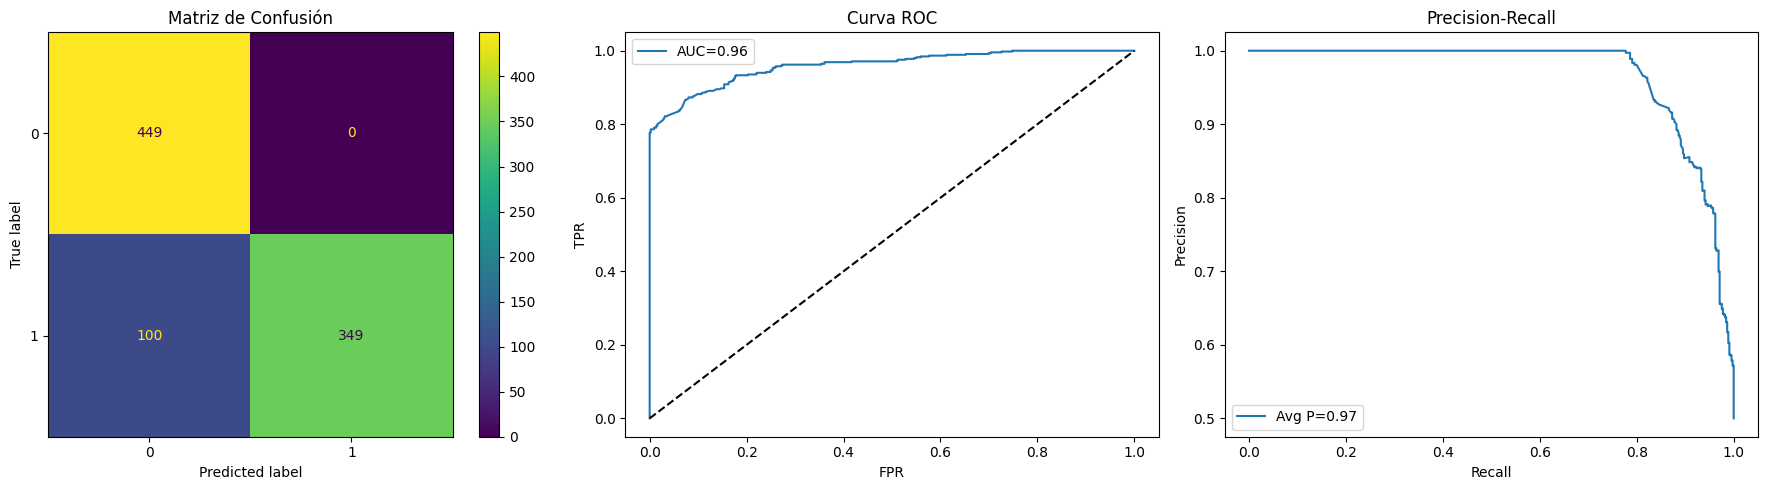

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot(ax=axes[0])
axes[0].set_title("Matriz de Confusión")

# Curva ROC
y_proba = model_rf.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, label=f"AUC={roc_auc_score(y_test,y_proba):.2f}")
axes[1].plot([0,1],[0,1],"k--"); axes[1].set_title("Curva ROC")
axes[1].set_xlabel("FPR"); axes[1].set_ylabel("TPR"); axes[1].legend()

# Precision-Recall
precision, recall, _ = precision_recall_curve(y_test, y_proba)
avg_p = average_precision_score(y_test, y_proba)
axes[2].plot(recall, precision, label=f"Avg P={avg_p:.2f}")
axes[2].set_title("Precision-Recall")
axes[2].set_xlabel("Recall"); axes[2].set_ylabel("Precision"); axes[2].legend()

plt.tight_layout()
plt.savefig("rf_metrics.png", dpi=120, bbox_inches="tight")
plt.show()

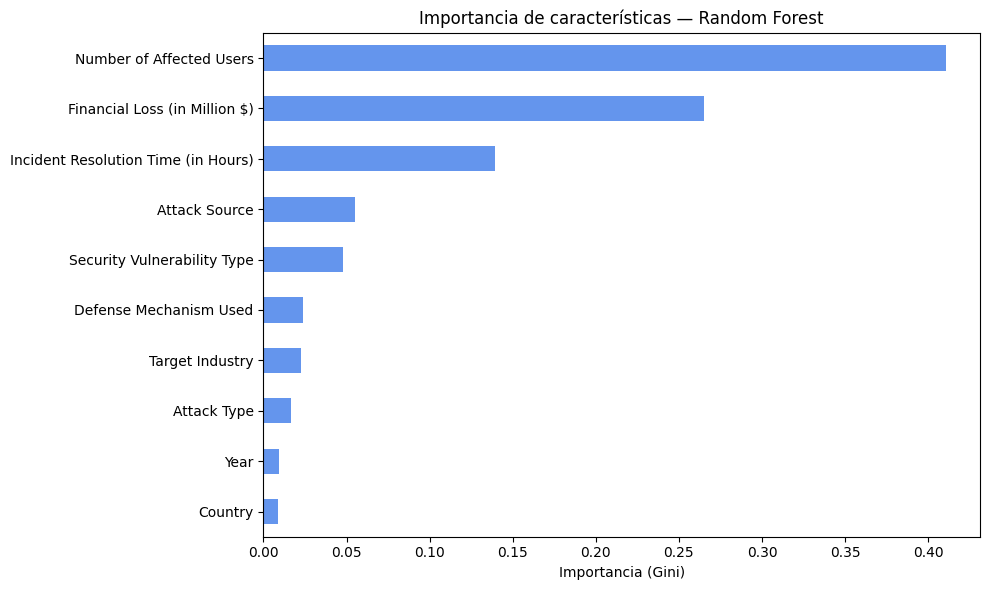

In [19]:
# Importancia de características
importances = model_rf.feature_importances_
feat_imp = pd.Series(importances, index=FEATURES).sort_values(ascending=True)
feat_imp.plot(kind="barh", figsize=(10, 6), color="cornflowerblue")
plt.title("Importancia de características — Random Forest")
plt.xlabel("Importancia (Gini)")
plt.tight_layout()
plt.savefig("rf_feature_importance.png", dpi=120, bbox_inches="tight")
plt.show()

---
## 5. Modelo RNN — LSTM Autoencoder (detección no supervisada)

In [20]:
# Preprocesamiento para LSTM
df_lstm = df_model.copy()
numerical_cols_lstm = ["Financial Loss (in Million $)", "Number of Affected Users",
                       "Incident Resolution Time (in Hours)", "Year"]
scaler_lstm = MinMaxScaler()
df_lstm[numerical_cols_lstm] = scaler_lstm.fit_transform(df_lstm[numerical_cols_lstm])

X_lstm = df_lstm[FEATURES].values
y_lstm = df_lstm["IsAnomaly"].values

X_tr, X_te = train_test_split(X_lstm, test_size=0.2, shuffle=False)
y_tr, y_te = train_test_split(y_lstm, test_size=0.2, shuffle=False)

def create_sequences(data, labels, time_steps=10):
    seqs, labs = [], []
    for i in range(len(data) - time_steps):
        seqs.append(data[i:i+time_steps])
        labs.append(labels[i+time_steps])
    return np.array(seqs), np.array(labs)

TIME_STEPS = 10
X_tr_seq, y_tr_seq = create_sequences(X_tr, y_tr, TIME_STEPS)
X_te_seq, y_te_seq = create_sequences(X_te, y_te, TIME_STEPS)
print(f"Train: {X_tr_seq.shape} | Test: {X_te_seq.shape}")

Train: (2390, 10, 10) | Test: (590, 10, 10)


In [21]:
# Definición del LSTM Autoencoder
n_features = X_tr_seq.shape[2]
inputs = Input(shape=(TIME_STEPS, n_features))
encoded = LSTM(64, activation="relu")(inputs)
decoded = RepeatVector(TIME_STEPS)(encoded)
decoded = LSTM(64, activation="relu", return_sequences=True)(decoded)
decoded = TimeDistributed(Dense(n_features))(decoded)

lstm_autoencoder = Model(inputs, decoded)
lstm_autoencoder.compile(optimizer="adam", loss="mse")
lstm_autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 10, 10)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        19,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 10, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 10, 10)         │           650 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,874 (206.54 KB)

 Trainable params: 52,874 (206.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - loss: 3.0487 - val_loss: 1.9011
Epoch 2/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.8996 - val_loss: 1.7901
Epoch 3/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 1.8386 - val_loss: 1.7555
Epoch 4/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 1.7915 - val_loss: 1.7190
Epoch 5/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.7456 - val_loss: 1.6844
Epoch 6/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 1.7044 - val_loss: 1.6654
Epoch 7/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 1.6702 - val_loss: 1.6336
Epoch 8/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.6293 - val_loss: 1.5959
Epoch 9/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.5935 - val_loss: 1.5567
Epoch 10/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 1.5509 - val_loss: 1.5206
Epoch 11/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 1.4961 - val_loss: 1.4661
Epoch 12/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.4

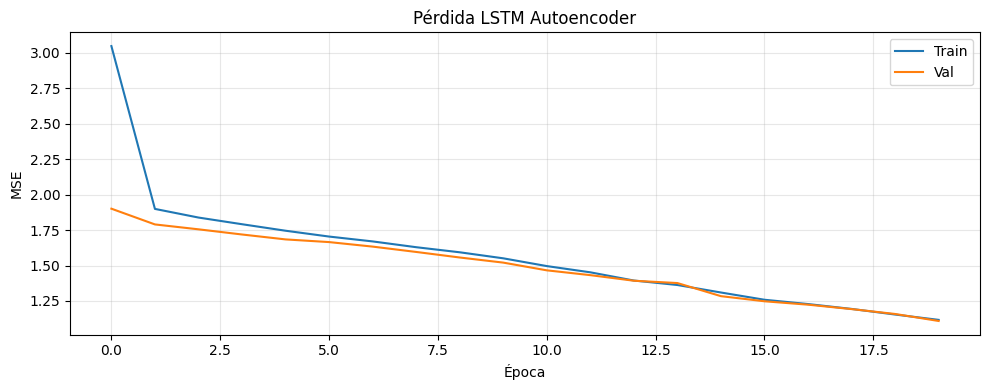

In [22]:
# Entrenamiento
history_lstm = lstm_autoencoder.fit(
    X_tr_seq, X_tr_seq,
    epochs=20, batch_size=32,
    validation_split=0.1,
    shuffle=False, verbose=1)

# Pérdida de entrenamiento
plt.figure(figsize=(10, 4))
plt.plot(history_lstm.history["loss"], label="Train")
plt.plot(history_lstm.history["val_loss"], label="Val")
plt.title("Pérdida LSTM Autoencoder"); plt.xlabel("Época"); plt.ylabel("MSE")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

In [23]:
# Detección de anomalías
recons = lstm_autoencoder.predict(X_te_seq)
mse_lstm = np.mean(np.power(X_te_seq - recons, 2), axis=(1, 2))
threshold_lstm = np.percentile(mse_lstm, 95)
y_pred_lstm = (mse_lstm > threshold_lstm).astype(int)

print("=== Métricas LSTM Autoencoder ===")
print(f"Accuracy : {accuracy_score(y_te_seq, y_pred_lstm):.4f}")
print(f"Precision: {precision_score(y_te_seq, y_pred_lstm, zero_division=0):.4f}")
print(f"Recall   : {recall_score(y_te_seq, y_pred_lstm, zero_division=0):.4f}")
print(f"F1-Score : {f1_score(y_te_seq, y_pred_lstm, zero_division=0):.4f}")

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step
=== Métricas LSTM Autoencoder ===
Accuracy : 0.7051
Precision: 0.1333
Recall   : 0.0263
F1-Score : 0.0440


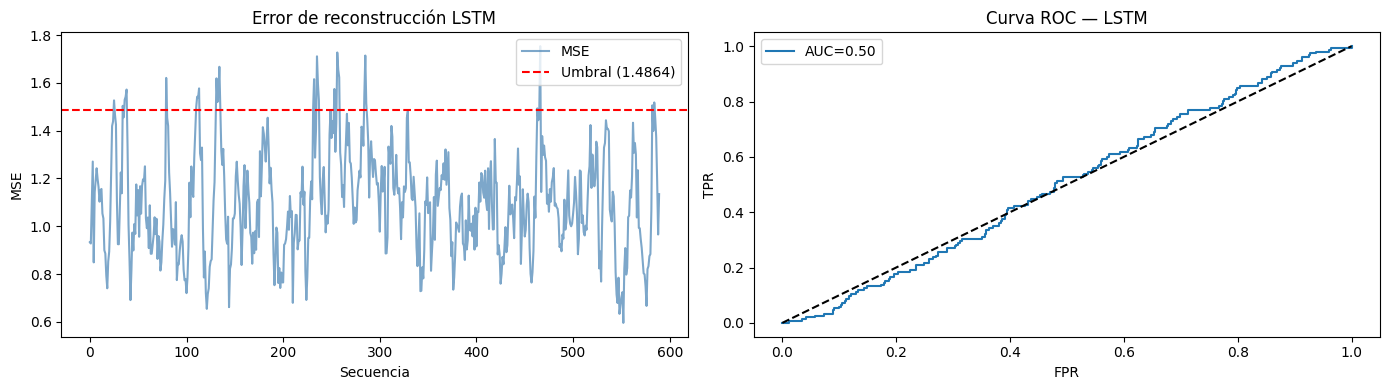

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Error de reconstrucción
axes[0].plot(mse_lstm, alpha=0.7, color="steelblue", label="MSE")
axes[0].axhline(threshold_lstm, color="red", linestyle="--", label=f"Umbral ({threshold_lstm:.4f})")
axes[0].set_title("Error de reconstrucción LSTM")
axes[0].set_xlabel("Secuencia"); axes[0].set_ylabel("MSE"); axes[0].legend()

# Curva ROC
fpr_l, tpr_l, _ = roc_curve(y_te_seq, mse_lstm)
auc_l = roc_auc_score(y_te_seq, mse_lstm)
axes[1].plot(fpr_l, tpr_l, label=f"AUC={auc_l:.2f}")
axes[1].plot([0,1],[0,1],"k--"); axes[1].set_title("Curva ROC — LSTM")
axes[1].set_xlabel("FPR"); axes[1].set_ylabel("TPR"); axes[1].legend()

plt.tight_layout()
plt.savefig("lstm_metrics.png", dpi=120, bbox_inches="tight")
plt.show()

---
## 6. Isolation Forest + PCA (detección no supervisada)

In [25]:
# Preparar datos para Isolation Forest
X_if = df_model[FEATURES].values
scaler_if = StandardScaler()
X_if_scaled = scaler_if.fit_transform(X_if)

CONTAMINATION = 0.05  # Ajusta según proporción esperada de anomalías
iso_forest = IsolationForest(n_estimators=100, contamination=CONTAMINATION,
                              max_samples="auto", random_state=42, n_jobs=-1)
iso_forest.fit(X_if_scaled)

df_model["iforest_score"] = iso_forest.decision_function(X_if_scaled)
df_model["iforest_anomaly"] = iso_forest.predict(X_if_scaled)  # 1=normal, -1=anomalía

n_anom = (df_model["iforest_anomaly"] == -1).sum()
print(f"✅ Anomalías detectadas: {n_anom} ({n_anom/len(df_model)*100:.1f}%)")

✅ Anomalías detectadas: 150 (5.0%)


Varianza explicada: PC1=10.65%, PC2=10.50%


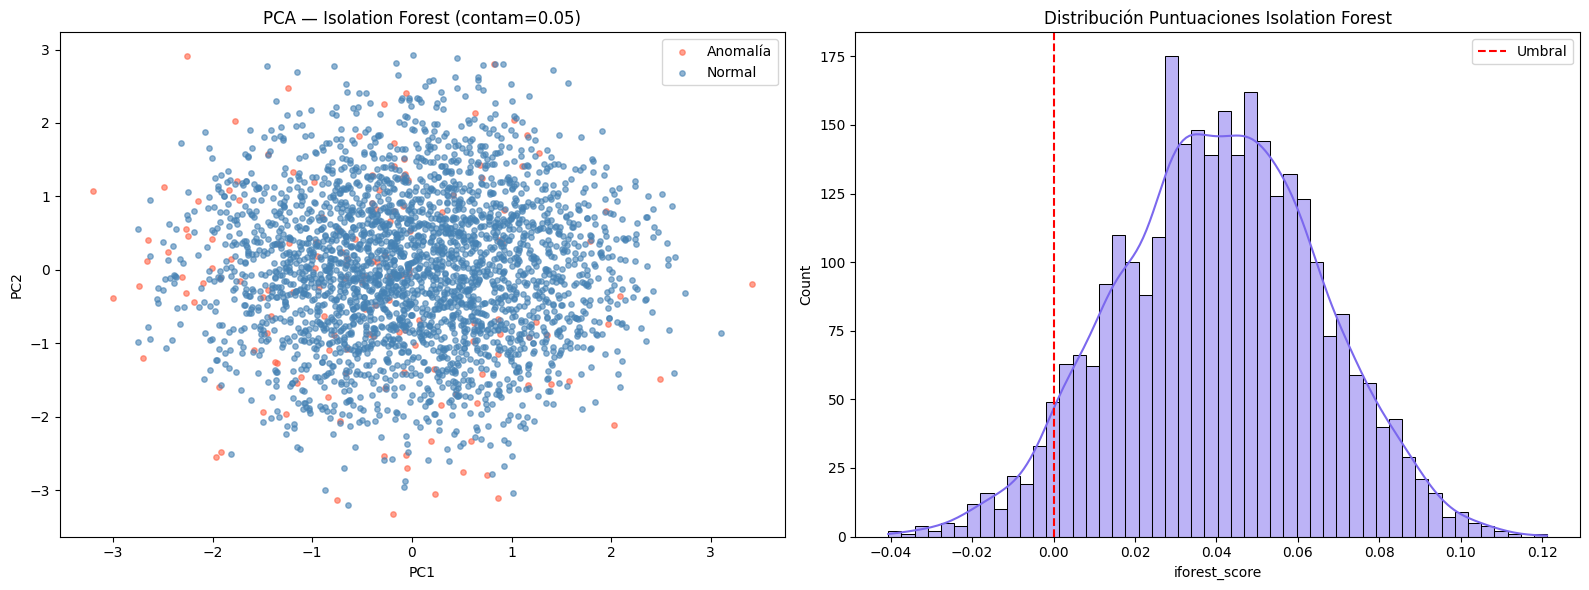

In [26]:
# PCA para visualización
features_pca = df_model.drop(columns=["iforest_score","iforest_anomaly","IsAnomaly",
                                       "Risk Score","Normalized Resolution Time"], errors="ignore")
scaler_pca = StandardScaler()
pca = PCA(n_components=2)
pcs = pca.fit_transform(scaler_pca.fit_transform(features_pca))

pca_df = pd.DataFrame(pcs, columns=["PC1","PC2"])
pca_df["anomaly"] = df_model["iforest_anomaly"].values

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter PCA
palette = {1: "steelblue", -1: "tomato"}
for label, grp in pca_df.groupby("anomaly"):
    tag = "Normal" if label == 1 else "Anomalía"
    axes[0].scatter(grp.PC1, grp.PC2, c=palette[label], label=tag, s=15, alpha=0.6)
axes[0].set_title(f"PCA — Isolation Forest (contam={CONTAMINATION})")
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2"); axes[0].legend()

# Distribución de scores
sns.histplot(df_model["iforest_score"], bins=50, kde=True, ax=axes[1], color="mediumslateblue")
thr = np.percentile(df_model["iforest_score"], CONTAMINATION*100)
axes[1].axvline(thr, color="red", linestyle="--", label="Umbral")
axes[1].set_title("Distribución Puntuaciones Isolation Forest")
axes[1].legend()

print(f"Varianza explicada: PC1={pca.explained_variance_ratio_[0]:.2%}, PC2={pca.explained_variance_ratio_[1]:.2%}")
plt.tight_layout()
plt.savefig("iforest_pca.png", dpi=120, bbox_inches="tight")
plt.show()

In [27]:
# Guardar Isolation Forest
os.makedirs("models", exist_ok=True)
joblib.dump(iso_forest, "models/isolation_forest.joblib")
joblib.dump(scaler_if,  "models/scaler_iforest.joblib")
print("✅ Modelo guardado en models/")

✅ Modelo guardado en models/


---
## 7. Autoencoder Denso (detección no supervisada)

In [28]:
FEATURE_COLS_AE = [
    "Country", "Year", "Attack Type", "Target Industry",
    "Financial Loss (in Million $)", "Number of Affected Users",
    "Attack Source", "Security Vulnerability Type",
    "Defense Mechanism Used", "Incident Resolution Time (in Hours)",
    "Risk Score", "Normalized Resolution Time"]

X_ae = df_model[FEATURE_COLS_AE].values
scaler_ae = StandardScaler()
X_ae_scaled = scaler_ae.fit_transform(X_ae)
X_ae_train, X_ae_val = train_test_split(X_ae_scaled, test_size=0.2, random_state=42)

input_dim = X_ae_scaled.shape[1]
latent_dim = 5

# Arquitectura
inp = Input(shape=(input_dim,))
enc = Dense(32, activation="relu")(inp)
enc = Dense(16, activation="relu")(enc)
enc = Dense(8, activation="relu")(enc)
lat = Dense(latent_dim, activation="relu")(enc)
dec = Dense(8, activation="relu")(lat)
dec = Dense(16, activation="relu")(dec)
dec = Dense(32, activation="relu")(dec)
out = Dense(input_dim, activation="linear")(dec)

autoencoder_dense = Model(inp, out)
autoencoder_dense.compile(optimizer=Adam(1e-3), loss=MeanSquaredError())
autoencoder_dense.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 12)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 5)              │            45 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 8)              │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 12)             │           396 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,257 (8.82 KB)

 Trainable params: 2,257 (8.82 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.9635 - val_loss: 0.9349
Epoch 2/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.8361 - val_loss: 0.8140
Epoch 3/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7355 - val_loss: 0.7451
Epoch 4/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6886 - val_loss: 0.7187
Epoch 5/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.6675 - val_loss: 0.7027
Epoch 6/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.6531 - val_loss: 0.6826
Epoch 7/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.6327 - val_loss: 0.6544
Epoch 8/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.6107 - val_loss: 0.6326
Epoch 9/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5961 - val_loss: 0.6202
Epoch 10/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5892 - val_loss: 0.6187
Epoch 11/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5864 - val_loss: 0.6198
Epoch 12/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5853 - val_lo

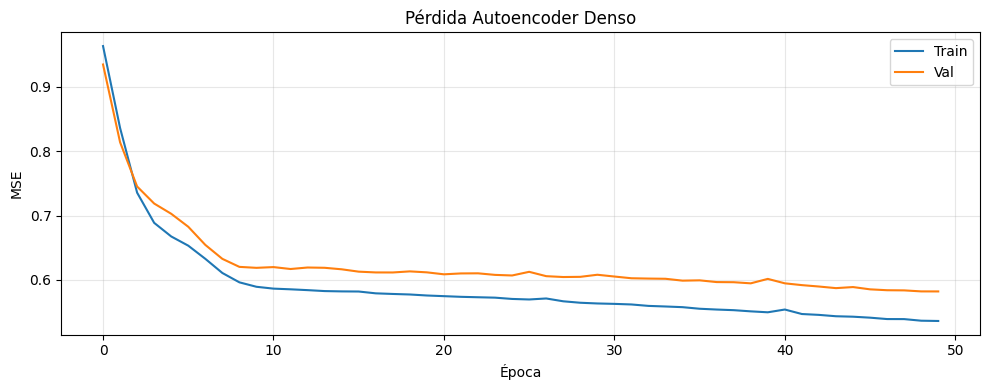

In [29]:
history_ae = autoencoder_dense.fit(
    X_ae_train, X_ae_train,
    epochs=50, batch_size=32,
    shuffle=True,
    validation_data=(X_ae_val, X_ae_val),
    verbose=1)

plt.figure(figsize=(10, 4))
plt.plot(history_ae.history["loss"],     label="Train")
plt.plot(history_ae.history["val_loss"], label="Val")
plt.title("Pérdida Autoencoder Denso"); plt.xlabel("Época"); plt.ylabel("MSE")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Umbral AE: 0.916184
Anomalías detectadas: 150 (5.0%)


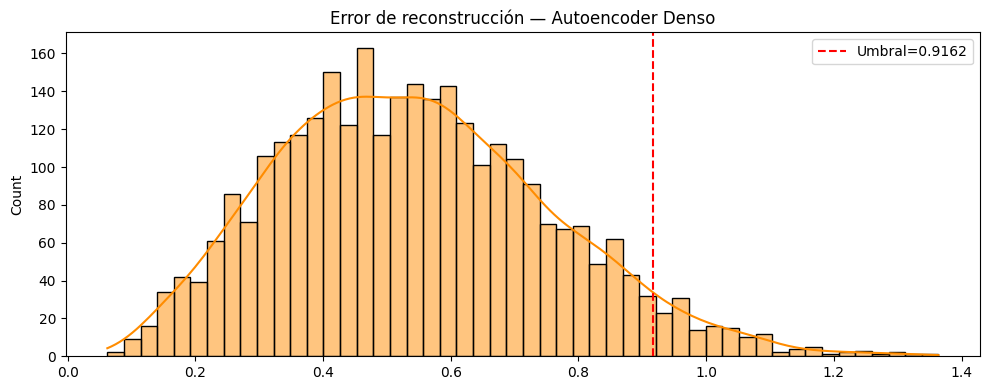

In [30]:
# Umbral y clasificación
recons_ae = autoencoder_dense.predict(X_ae_scaled)
mse_ae = np.mean(np.square(X_ae_scaled - recons_ae), axis=1)
threshold_ae = np.percentile(mse_ae, 95)
df_model["ae_recon_error"] = mse_ae
df_model["ae_anomaly"] = (mse_ae > threshold_ae).astype(int)

n_ae = df_model["ae_anomaly"].sum()
print(f"Umbral AE: {threshold_ae:.6f}")
print(f"Anomalías detectadas: {n_ae} ({n_ae/len(df_model)*100:.1f}%)")

# Distribución
plt.figure(figsize=(10, 4))
sns.histplot(mse_ae, bins=50, kde=True, color="darkorange")
plt.axvline(threshold_ae, color="red", linestyle="--", label=f"Umbral={threshold_ae:.4f}")
plt.title("Error de reconstrucción — Autoencoder Denso")
plt.legend(); plt.tight_layout(); plt.show()

In [31]:
# Guardar Autoencoder
os.makedirs("models", exist_ok=True)
autoencoder_dense.save("models/autoencoder_dense.keras")
joblib.dump(scaler_ae, "models/scaler_ae.joblib")
print("✅ Autoencoder guardado en models/")

✅ Autoencoder guardado en models/


---
## 8. Algoritmo de Grover (Qiskit) — Estimación de ataques cuánticos

> Requiere: 

In [34]:
from math import pi, sqrt
from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer

def phase_oracle_circuit(n, target):
    """Oráculo de fase: aplica -1 al estado |target>."""
    qc = QuantumCircuit(n)
    bitstr = format(target, f"0{n}b")
    for i, b in enumerate(bitstr):
        if b == "0":
            qc.x(i)
    qc.h(n-1)
    if n > 1:
        qc.mcx(list(range(n-1)), n-1)
    else:
        qc.z(0)
    qc.h(n-1)
    for i, b in enumerate(bitstr):
        if b == "0":
            qc.x(i)
    return qc

def diffuser_circuit(n):
    """Difusor de Grover (reflexión sobre el estado uniforme)."""
    qc = QuantumCircuit(n)
    qc.h(range(n)); qc.x(range(n))
    qc.h(n-1)
    if n > 1:
        qc.mcx(list(range(n-1)), n-1)
    else:
        qc.z(0)
    qc.h(n-1)
    qc.x(range(n)); qc.h(range(n))
    return qc

print("✅ Oráculo y difusor definidos")

✅ Oráculo y difusor definidos


In [37]:
def run_grover(n, target, shots=1024):
    """
    Ejecuta el algoritmo de Grover en el simulador Aer.
    Devuelve dict con resultados y métricas de tiempo.
    """
    qc = QuantumCircuit(n, n)
    qc.h(range(n))

    oracle = phase_oracle_circuit(n, target)
    diff   = diffuser_circuit(n)

    N     = 2**n
    iters = max(1, int(math.floor((pi/4)*sqrt(N))))

    for _ in range(iters):
        qc.append(oracle.to_gate(), range(n))
        qc.append(diff.to_gate(), range(n))
    qc.measure(range(n), range(n))

    sim = Aer.get_backend("aer_simulator")

    # Tiempo de transpilación
    t0 = time.time()
    tqc = transpile(qc, sim, optimization_level=3)
    t_transpile = time.time() - t0

    # Conteo de puertas del oráculo
    oracle_t = transpile(oracle, sim, optimization_level=3)
    oracle_ops = oracle_t.count_ops()
    oracle_total_gates = sum(oracle_ops.values())

    # Ejecución y tiempo
    t0 = time.time()
    result = sim.run(tqc, shots=shots).result()
    t_exec = time.time() - t0

    counts = result.get_counts()
    t_oracle_est = t_exec / iters if iters > 0 else None

    return {
        "counts": counts, "iters": iters, "qc": qc,
        "transpile_time": t_transpile, "exec_time": t_exec,
        "t_oracle_est": t_oracle_est,
        "oracle_ops": dict(oracle_ops),
        "oracle_total_gates": oracle_total_gates}

# Prueba con n=6, target=19
res = run_grover(6, 19, shots=2048)
print(f"Iteraciones: {res['iters']}")
print(f"Transpile time : {res['transpile_time']:.4f} s")
print(f"Exec time      : {res['exec_time']:.4f} s")
print(f"t_oracle (est) : {res['t_oracle_est']:.6f} s")
print(f"Oracle gates   : {res['oracle_total_gates']}")

Iteraciones: 6
Transpile time : 0.4228 s
Exec time      : 0.0206 s
t_oracle (est) : 0.003428 s
Oracle gates   : 9


In [38]:
# ── Funciones de extrapolación ──
def time_classic(n, R_cl=1e9):
    """Tiempo búsqueda clásica exhaustiva (N/2 intentos a R_cl keys/s)."""
    return (2**n / 2.0) / R_cl

def time_grover_theoretical(n, t_oracle):
    """Tiempo cuántico teórico: (π/4)√N × t_oracle."""
    if t_oracle is None: return None
    return ((pi/4) * sqrt(2**n)) * t_oracle

def human_readable(sec):
    if sec is None: return "N/A"
    if sec < 1:     return f"{sec:.3e} s"
    if sec < 60:    return f"{sec:.3f} s"
    if sec < 3600:  return f"{sec/60:.2f} min"
    if sec < 86400: return f"{sec/3600:.2f} h"
    days = sec/86400
    if days < 365:  return f"{days:.1f} días"
    return f"{days/365:.2e} años"

# Tabla de extrapolación
t_oracle = res["t_oracle_est"]
t_oracle_theory = 1e-6  # supuesto optimista para comparación

print(f"{'n':>5} | {'N':>15} | {'Clásico (t_oracle medido)':>28} | {'Grover (medido)':>20} | {'Grover (1µs teórico)':>22}")
print("-"*100)
for n in [8, 12, 20, 32, 48, 64, 128]:
    Tcl = time_classic(n)
    Tq_emp = time_grover_theoretical(n, t_oracle)
    Tq_teo = time_grover_theoretical(n, t_oracle_theory)
    print(f"{n:>5} | {2**n:>15,.0f} | {human_readable(Tcl):>28} | {human_readable(Tq_emp):>20} | {human_readable(Tq_teo):>22}")

    n |               N |    Clásico (t_oracle medido) |      Grover (medido) |   Grover (1µs teórico)
----------------------------------------------------------------------------------------------------
    8 |             256 |                  1.280e-07 s |          4.307e-02 s |            1.257e-05 s
   12 |           4,096 |                  2.048e-06 s |          1.723e-01 s |            5.027e-05 s
   20 |       1,048,576 |                  5.243e-04 s |              2.757 s |            8.042e-04 s
   32 |   4,294,967,296 |                      2.147 s |             2.94 min |            5.147e-02 s
   48 | 281,474,976,710,656 |                     1.6 días |              12.55 h |               13.177 s
   64 | 18,446,744,073,709,551,616 |                2.92e+02 años |           133.8 días |              56.22 min
  128 | 340,282,366,920,938,463,463,374,607,431,768,211,456 |                5.40e+21 años |        1.57e+09 años |          4.59e+05 años


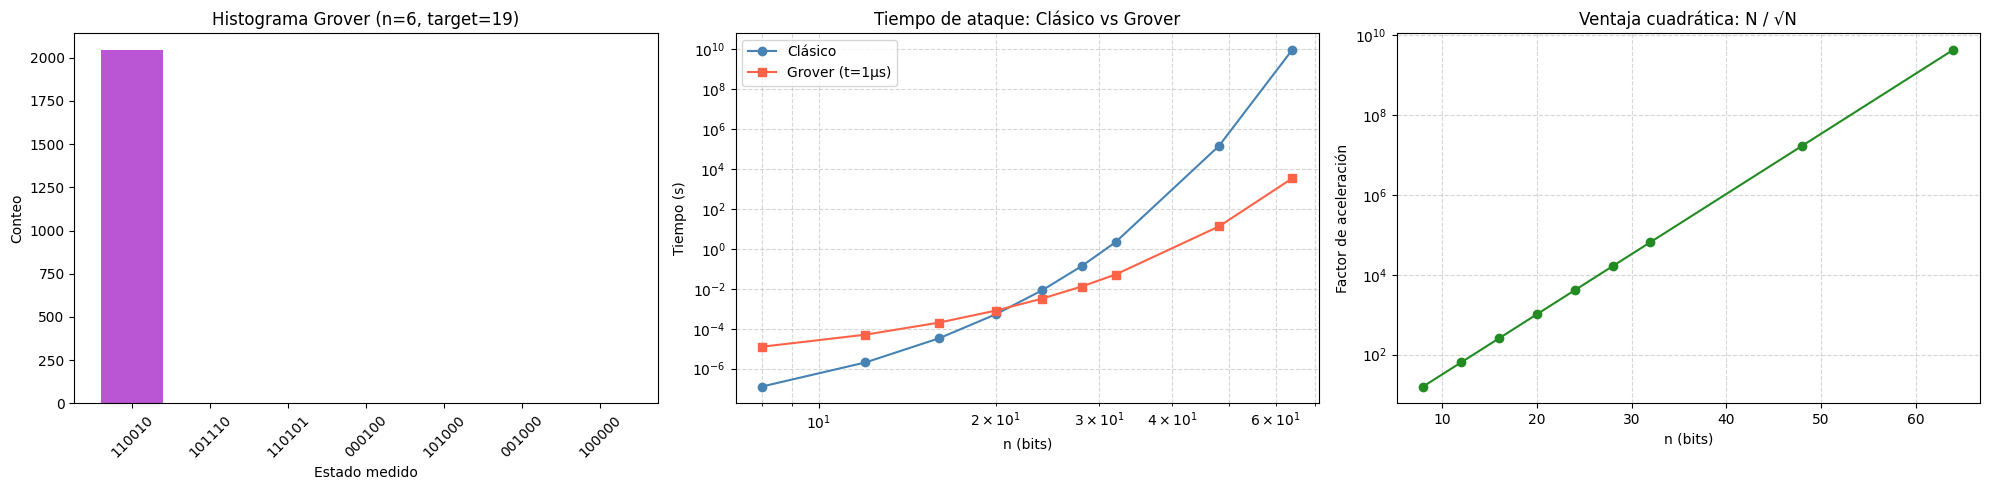

In [39]:
# ── Visualizaciones Grover ──
from qiskit.visualization import plot_histogram

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 1. Histograma de conteos
top_counts = dict(sorted(res["counts"].items(), key=lambda x: -x[1])[:10])
axes[0].bar(top_counts.keys(), top_counts.values(), color="mediumorchid")
axes[0].set_title("Histograma Grover (n=6, target=19)")
axes[0].set_xlabel("Estado medido"); axes[0].set_ylabel("Conteo")
axes[0].tick_params(axis="x", rotation=45)

# 2. Log-log Clásico vs Grover
ns_plot = [8, 12, 16, 20, 24, 28, 32, 48, 64]
T_cl_list  = [time_classic(n) for n in ns_plot]
T_q_list   = [time_grover_theoretical(n, t_oracle_theory) for n in ns_plot]

axes[1].loglog(ns_plot, T_cl_list, "o-", label="Clásico", color="steelblue")
axes[1].loglog(ns_plot, T_q_list,  "s-", label="Grover (t=1µs)", color="tomato")
axes[1].set_title("Tiempo de ataque: Clásico vs Grover")
axes[1].set_xlabel("n (bits)"); axes[1].set_ylabel("Tiempo (s)")
axes[1].legend(); axes[1].grid(True, which="both", ls="--", alpha=0.5)

# 3. Ventaja cuadrática (ratio N vs √N)
ratios = [(2**n) / sqrt(2**n) for n in ns_plot]
axes[2].semilogy(ns_plot, ratios, "o-", color="forestgreen")
axes[2].set_title("Ventaja cuadrática: N / √N")
axes[2].set_xlabel("n (bits)"); axes[2].set_ylabel("Factor de aceleración")
axes[2].grid(True, which="both", ls="--", alpha=0.5)

plt.tight_layout()
plt.savefig("grover_analysis.png", dpi=120, bbox_inches="tight")
plt.show()

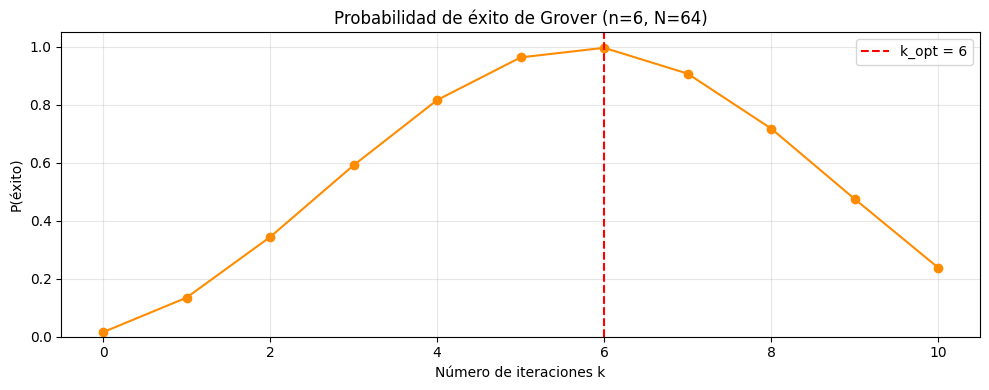

In [40]:
# ── Probabilidad de éxito por iteración ──
def success_probability(k, N):
    """P(éxito) después de k iteraciones de Grover."""
    theta = math.asin(1/sqrt(N))
    return math.sin((2*k + 1)*theta)**2

n_demo = 6
N_demo = 2**n_demo
k_vals = range(0, int((pi/4)*sqrt(N_demo)) + 5)
probs  = [success_probability(k, N_demo) for k in k_vals]

plt.figure(figsize=(10, 4))
plt.plot(k_vals, probs, "o-", color="darkorange")
plt.axvline(int((pi/4)*sqrt(N_demo)), color="red", linestyle="--",
            label=f"k_opt = {int((pi/4)*sqrt(N_demo))}")
plt.title(f"Probabilidad de éxito de Grover (n={n_demo}, N={N_demo})")
plt.xlabel("Número de iteraciones k"); plt.ylabel("P(éxito)")
plt.legend(); plt.grid(alpha=0.3); plt.ylim(0, 1.05)
plt.tight_layout()
plt.savefig("grover_success_prob.png", dpi=120, bbox_inches="tight")
plt.show()

---
## 9. Resumen de Resultados

In [43]:
print("="*60)
print("RESUMEN — QuantumCyberGuard")
print("="*60)

# RF
from sklearn.metrics import accuracy_score
acc_rf = accuracy_score(y_test, y_pred)
print(f"[1] Random Forest (supervisado)")
print(f"    Accuracy : {acc_rf:.4f}")
print(f"    AUC-ROC  : {roc_auc_score(y_test, y_proba):.4f}")

# LSTM
acc_lstm = accuracy_score(y_te_seq, y_pred_lstm)
print(f"[2] LSTM Autoencoder (no supervisado)")
print(f"    Accuracy : {acc_lstm:.4f}")
print(f"    AUC-ROC  : {roc_auc_score(y_te_seq, mse_lstm):.4f}")

# IF
print(f"[3] Isolation Forest")
print(f"    Anomalías: {(df_model.iforest_anomaly==-1).sum()} ({(df_model.iforest_anomaly==-1).mean()*100:.1f}%)")

# AE
print(f"[4] Autoencoder Denso")
print(f"    Anomalías: {df_model.ae_anomaly.sum()} ({df_model.ae_anomaly.mean()*100:.1f}%)")

# Grover
print(f"[5] Algoritmo de Grover (n=6, target=19)")
print(f"    Iteraciones óptimas : {res['iters']}")
print(f"    t_oracle estimado   : {res['t_oracle_est']:.6f} s")
print(f"    Oracle gates        : {res['oracle_total_gates']}")
print(f"")
print(f"    Extrapolación (t_oracle=1µs teórico):")
for n_b in [64, 128]:
    Tq = time_grover_theoretical(n_b, 1e-6)
    Tc = time_classic(n_b)
    print(f"      n={n_b} bits | Clásico: {human_readable(Tc)} | Grover: {human_readable(Tq)}")
print("="*60)

RESUMEN — QuantumCyberGuard
[1] Random Forest (supervisado)
    Accuracy : 0.8886
    AUC-ROC  : 0.9592
[2] LSTM Autoencoder (no supervisado)
    Accuracy : 0.7051
    AUC-ROC  : 0.5044
[3] Isolation Forest
    Anomalías: 150 (5.0%)
[4] Autoencoder Denso
    Anomalías: 150 (5.0%)
[5] Algoritmo de Grover (n=6, target=19)
    Iteraciones óptimas : 6
    t_oracle estimado   : 0.003428 s
    Oracle gates        : 9

    Extrapolación (t_oracle=1µs teórico):
      n=64 bits | Clásico: 2.92e+02 años | Grover: 56.22 min
      n=128 bits | Clásico: 5.40e+21 años | Grover: 4.59e+05 años
